<a href="https://colab.research.google.com/github/zippyritmik/compfin/blob/master/v2.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Black–Litterman Portfolio Allocation for a European Single Family Office

**1. IMPORT LIBRARIES**

- `yfinance` downloads historical market prices.
- `pandas_datareader` downloads the German government bond yield series from FRED.
- `risk_models` helps estimate portfolio risk.
- `BlackLittermanModel` applies the Black–Litterman approach.
- `market_implied_prior_returns` calculates equilibrium returns implied by the benchmark portfolio.
- `EfficientFrontier` optimizes the final portfolio weights.
- `PercentFormatter` formats chart axes as percentages.
- `matplotlib.cm` is used for red color gradients in visualizations.
- `numpy` supports numerical calculations and color-scale generation.
- `pd.options.display.float_format` makes output tables easier to read.

In [ ]:
!pip install yfinance PyPortfolioOpt pandas_datareader openpyxl

# Run this cell if the packages are not already installed.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm #cm colormap (clear visualization)
import yfinance as yf #download historical data from Yahoo (Accessible)

from matplotlib.ticker import PercentFormatter #format charts -> 0.55 -> 50%
from pandas_datareader import data as pdr #download data from database -> FRED

from pypfopt import risk_models #Python package for portfolio optimization, calculating risk measures, especially the covariance matrix.
from pypfopt.black_litterman import ( #combine market equilibrium returns with our own macroeconomic views
    BlackLittermanModel,
    market_implied_prior_returns #calculate the prior expected returns, meaning the returns implied by the market portfolio before adding our own views.
)
from pypfopt.efficient_frontier import EfficientFrontier #helps choose the best weights based on expected return and risk.

pd.options.display.float_format = "{:.4f}".format #This controls how decimal numbers are displayed in pandas tables. (4 decimal places)

**2. DEFINE ASSET UNIVERSE**

* The asset universe defines which assets are included in the portfolio model.
* ETFs, indices and one bond-yield series are used as proxies for the selected asset classes.
* The selected proxies cover equities, bonds, Private Equity, gold and cash.
* This step is important because all later calculations depend on the selected assets.
* If one asset proxy is changed later, the return data, covariance matrix, benchmark weights and final results must also be updated.
* Most asset prices are downloaded from Yahoo Finance.
* German government bond data is handled separately because it is available as a yield series, not as a normal price series.


In [ ]:
# Yahoo Finance tickers
yahoo_tickers = [ #This creates a variable.
    "^SP500TR",  # US Equities
    "VGK",       # EU Equities
    "EWJ",       # Japan Equities
    "EEM",       # Emerging Market Equities
    "IEF",       # US Treasuries
    "LQD",       # US Investment Grade Bonds
    "PSP",       # Listed Private Equity Proxy
    "GC=F",      # Gold Futures
    "XEON.DE"    # EUR Cash Proxy
]

# German government bond yield from FRED
german_bond_fred_ticker = "IRLTLT01DEM156N" #defines the ticker/code for German government bond yield data.

asset_names = { #This creates a dictionary.(Readable namings-renaming)
    "^SP500TR": "US Equities",
    "VGK": "EU Equities",
    "EWJ": "Japan Equities",
    "EEM": "EM Equities",
    "IEF": "US Treasuries",
    "LQD": "US IG Bonds",
    "DE_BONDS": "German Bonds",
    "PSP": "Listed Private Equity Proxy",
    "GC=F": "Gold",
    "XEON.DE": "Cash EUR"
}

- A ticker is the symbol used to download financial market data.
- Most assets use Yahoo Finance tickers, such as `VGK`, `EEM`, `IEF` and `LQD`.
- German government bonds use a FRED data series code instead of a normal Yahoo Finance ticker.
- `IRLTLT01DEM156N` represents the German 10-year government bond yield.
- Since this is a yield series and not a price series, it must be converted into approximate bond returns before it can be used in the portfolio model.

**3. DOWNLOAD HISTORICAL PRICE DATA**

In [ ]:
START_DATE = "2008-01-01" #define time
END_DATE = "2026-01-01"

raw_data = yf.download( #This downloads historical data
    yahoo_tickers, #we defined above
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True, #the price series reflects adjusted market prices
    progress=False #hides download output thingy
)

prices = raw_data["Close"] #keeps only the "Close" price.

# Convert daily prices into month-end prices
monthly_prices = prices.resample("ME").last() #group the data by month-end, last() takes the last available price in each month.

# EURUSD=X means: 1 EUR = X USD
eurusd_data = yf.download(
    "EURUSD=X",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

# Handle Yahoo Finance output format
if isinstance(eurusd_data.columns, pd.MultiIndex):
    eurusd = eurusd_data["Close"]["EURUSD=X"]
else:
    eurusd = eurusd_data["Close"]

eurusd_monthly = eurusd.resample("ME").last().ffill()
eurusd_monthly.name = "EURUSD"

# These Yahoo Finance assets are USD-denominated and must be converted into EUR
usd_denominated_tickers = [
    "^SP500TR",
    "VGK",
    "EWJ",
    "EEM",
    "IEF",
    "LQD",
    "PSP",
    "GC=F"
]

# XEON.DE is already EUR-denominated
monthly_prices_eur = monthly_prices.copy()

eurusd_monthly_aligned = eurusd_monthly.reindex(monthly_prices_eur.index).ffill()

for ticker in usd_denominated_tickers:
    monthly_prices_eur[ticker] = monthly_prices_eur[ticker] / eurusd_monthly_aligned

print("Monthly price data:")
display(monthly_prices.head())

print("Missing values by asset:")
display(monthly_prices.isna().sum().to_frame("Missing Values"))

Monthly price data:


Ticker,EEM,EWJ,GC=F,IEF,LQD,PSP,VGK,XEON.DE,^SP500TR
Date,,,,,,,,,
2008-01-31,30.9378,36.7186,922.7000,57.4202,52.7537,33.8564,34.2122,132.7590,2167.8999
2008-02-29,31.5548,36.1701,972.1000,58.1319,52.3811,33.1432,34.1117,133.1760,2097.4800
2008-03-31,30.3706,35.7082,916.2000,58.9092,52.0683,31.1522,34.5589,133.6280,2088.4199
2008-04-30,33.1459,38.3351,862.8000,57.4852,52.7164,32.5485,35.9756,134.0560,2190.1299
2008-05-31,34.1946,39.0856,887.3000,56.4633,51.5539,33.4633,36.2167,134.4880,2218.5000


Missing values by asset:


,Missing Values
Ticker,
EEM,0
EWJ,0
GC=F,0
IEF,0
LQD,0
PSP,0
VGK,0
XEON.DE,0
^SP500TR,0


**VISUALIZATION: NORMALIZED PRICE DEVELOPMENT**

- This chart shows how the selected Yahoo Finance assets developed over time.
- All assets start at 100, so their performance can be compared more easily.
- German bonds are not included here because they are downloaded as a yield series, not a price series.

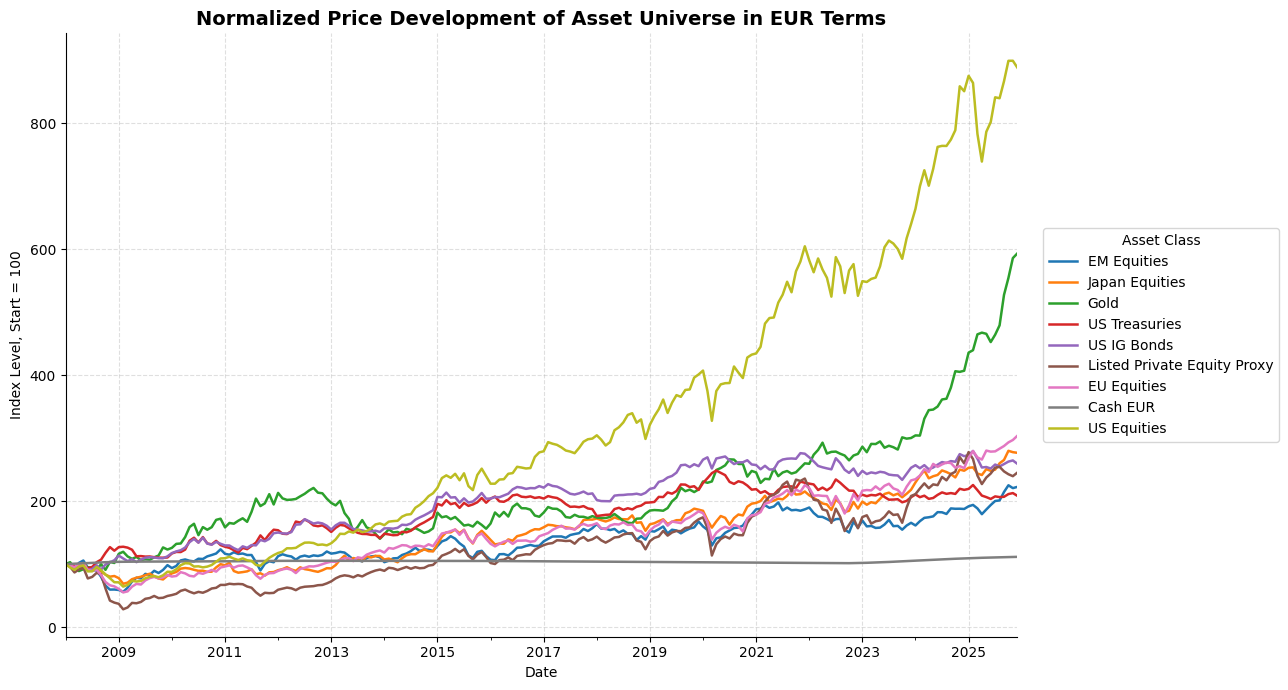

In [ ]:
#USD-denominated assets are converted into EUR terms before normalization.
fig, ax = plt.subplots(figsize=(13, 7)) #set the size

# Create normalized price index
normalized_prices = monthly_prices_eur / monthly_prices_eur.iloc[0] * 100 #divides every monthly price by the first price of that same asset.

# Convert ticker names into asset-class names e.g. "VGK" becomes "EU Equities"
normalized_prices_named = normalized_prices.copy() #We create a copy so that we can rename the columns for visualization without affecting the original data.
normalized_prices_named.columns = [
    asset_names.get(ticker, ticker) for ticker in normalized_prices_named.columns #replace ticker symbols with readable asset-class names so that the chart legend is easier to understand.
]

# Plot all Yahoo Finance assets
normalized_prices_named.plot(
    ax=ax, #draw the plot on the chart area we created earlier.
    linewidth=1.8
)

ax.set_title("Normalized Price Development of Asset Universe in EUR Terms", fontsize=14, weight="bold")
ax.set_ylabel("Index Level, Start = 100")
ax.set_xlabel("Date")

ax.grid(True, linestyle="--", alpha=0.4)

# Move legend outside the chart
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Asset Class"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**4. DOWNLOAD GERMAN GOVERNMENT BOND YIELD DATA**

* German government bond data is downloaded separately from FRED.
* The selected FRED series represents the German 10-year government bond yield.
* This data is not a normal price series like an ETF.
* The yield data is later converted into approximate monthly bond returns.
* This step is needed because German government bonds are part of the strategic benchmark portfolio.


In [ ]:
german_bond_fred_ticker = "IRLTLT01DEM156N"

fred_url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={german_bond_fred_ticker}"

german_yield = pd.read_csv(fred_url)

german_yield["observation_date"] = pd.to_datetime(german_yield["observation_date"])
german_yield = german_yield.set_index("observation_date")

german_yield[german_bond_fred_ticker] = pd.to_numeric(
    german_yield[german_bond_fred_ticker],
    errors="coerce"
)

german_yield = german_yield.loc[START_DATE:END_DATE]
german_yield = german_yield.resample("ME").last().ffill()

print("German 10-Year Government Bond Yield:")
display(german_yield.head())

print("Missing values:")
display(german_yield.isna().sum().to_frame("Missing Values"))

German 10-Year Government Bond Yield:


,IRLTLT01DEM156N
observation_date,
2008-01-31,4.0277
2008-02-29,3.9529
2008-03-31,3.7995
2008-04-30,4.0400
2008-05-31,4.2019


Missing values:


,Missing Values
IRLTLT01DEM156N,0


**5. CONVERT GERMAN BOND YIELD INTO APPROXIMATE RETURNS**

* The German bond data is available as a yield, not as a price.
* Portfolio calculations require returns, so the yield series must be converted.
* A duration-based approximation is used to estimate monthly bond returns.
* The duration assumption shows how sensitive the bond price is to changes in interest rates.
* If yields rise, bond prices usually fall.
* If yields fall, bond prices usually rise.
* The converted German bond return series is then added to the other asset return data.


In [ ]:
modified_duration_assumption = 8 #This sets the assumed bond duration to 8.

german_yield_decimal = german_yield[german_bond_fred_ticker] / 100 #We convert the German bond yield from percentage format into decimal format, because the return formula uses decimals.

german_bond_returns = (
    german_yield_decimal / 12 #income return.
    - modified_duration_assumption * german_yield_decimal.diff() #This estimates the price effect from changes in yield.
)

german_bond_returns.name = "DE_BONDS" #name this return series DE_BONDS so that it can later be merged with the other asset return data.

print("Approximate German bond returns:")
display(german_bond_returns.head())

Approximate German bond returns:


,DE_BONDS
observation_date,
2008-01-31,NaN
2008-02-29,0.0093
2008-03-31,0.0154
2008-04-30,-0.0159
2008-05-31,-0.0095


**6. CALCULATE MONTHLY RETURNS**

* Monthly returns are calculated from EUR-denominated month-end prices.
* Returns show how much each asset increased or decreased from one month to the next.
* German bond returns are added to the same dataset after being converted from yields.
* Rows with missing values are removed so all assets use the same time period.
* The final dataset starts in February 2008 and ends in December 2025.
* These monthly returns are the basis for the risk and portfolio calculations.
* USD-denominated assets are converted into EUR terms before return calculation.

In [ ]:
#This cell creates the final monthly return dataset that will later be used for the covariance matrix, Black-Litterman model, and optimization.
#Yahoo monthly prices → Yahoo monthly returns
#German yield → approximate German bond returns
#Then combine both into one return table
#Then clean and reorder the columns
yahoo_monthly_returns = monthly_prices_eur.pct_change() #This calculates monthly returns for all Yahoo Finance assets.

monthly_returns = pd.concat( #This combines the Yahoo asset returns with the German bond returns.
    [yahoo_monthly_returns, german_bond_returns],
    axis=1
)

# Keep only rows where all assets have return data
monthly_returns = monthly_returns.dropna()

# Reorder columns according to our portfolio structure
#We define the final asset order so the portfolio table follows the structure we want: equities first, then bonds, alternatives, gold, and cash.
final_tickers = [
    "^SP500TR",
    "VGK",
    "EWJ",
    "EEM",
    "IEF",
    "LQD",
    "DE_BONDS",
    "PSP",
    "GC=F",
    "XEON.DE"
]

monthly_returns = monthly_returns[final_tickers] #this reorders the columns of monthly_returns according to the final_tickers list.

print("Monthly returns:")
display(monthly_returns.tail())

print("Number of monthly observations:", len(monthly_returns))
print("Start date:", monthly_returns.index.min())
print("End date:", monthly_returns.index.max())

Monthly returns:


,^SP500TR,VGK,EWJ,EEM,IEF,LQD,DE_BONDS,PSP,GC=F,XEON.DE
2025-08-31,-0.0018,0.0153,0.0403,0.0046,-0.0055,-0.0114,-0.0011,0.0057,0.0320,0.0017
2025-09-30,0.0321,0.0149,0.0203,0.0664,0.0022,0.0144,0.0007,-0.0286,0.1010,0.0015
2025-10-31,0.0375,0.0201,0.0547,0.0498,0.0209,0.0153,0.0082,-0.0183,0.0511,0.0019
2025-11-30,0.0001,0.0129,-0.0076,-0.0200,0.0075,0.0069,-0.0010,-0.0127,0.0568,0.0015
2025-12-31,-0.0119,0.0222,-0.0036,0.0088,-0.0201,-0.0198,-0.0102,0.0233,0.0126,0.0019


Number of monthly observations: 215
Start date: 2008-02-29 00:00:00
End date: 2025-12-31 00:00:00


**7. CALCULATE ANNUALIZED RETURNS AND VOLATILITY**

- Annualized returns show the average yearly return of each asset.
- Annualized volatility shows the yearly risk level of each asset.
- Higher volatility means larger price movements.
- These statistics help compare the risk-return profile of the selected assets.
- The results are based on monthly returns from February 2008 to December 2025.

monthly_returns -> mean monthly return -> annualised return -> monthly_returns -> monthly standard deviation -> annualised volatility

In [ ]:
annualised_returns = monthly_returns.mean() * 12 #calculate the average monthly return for each asset and multiply it by 12 to approximate the annual return.
annualised_volatility = monthly_returns.std() * np.sqrt(12) #use square root of 12 because volatility scales with the square root of time, not linearly.

summary_statistics = pd.DataFrame({ #creates a pandas DataFrame
    "Annualised Return": annualised_returns,
    "Annualised Volatility": annualised_volatility
})

summary_statistics.index = [asset_names[ticker] for ticker in summary_statistics.index] #This changes the row names from ticker symbols into readable asset names.

display(summary_statistics)

,Annualised Return,Annualised Volatility
US Equities,0.1330,0.1452
EU Equities,0.0739,0.1532
Japan Equities,0.0670,0.1416
EM Equities,0.0588,0.1671
US Treasuries,0.0469,0.1089
US IG Bonds,0.0583,0.1005
German Bonds,0.0194,0.0468
Listed Private Equity Proxy,0.0790,0.2328
Gold,0.1121,0.1587
Cash EUR,0.0061,0.0044


**VISUALIZATION: RISK-RETURN PROFILE**

- This chart compares annualized return and annualized volatility.
- Assets further to the right have higher risk.
- Assets higher on the chart have higher historical return.
- This helps show the risk-return tradeoff across the asset universe.

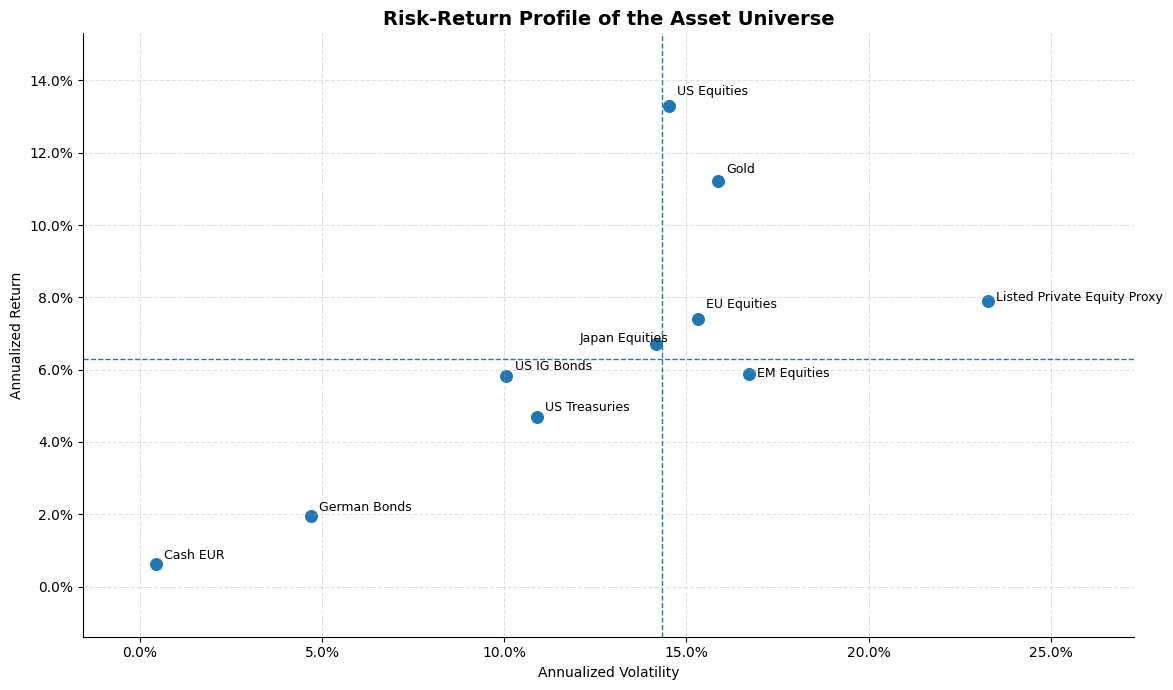

In [ ]:
# Create the chart area.
fig, ax = plt.subplots(figsize=(12, 7))

# Use annualised volatility as the x-axis.
# Volatility represents risk.
x = summary_statistics["Annualised Volatility"]

# Use annualised return as the y-axis.
# Return represents historical performance.
y = summary_statistics["Annualised Return"]

# Create the scatter plot.
# Each dot represents one asset class.
# s=70 controls the size of the dots.
ax.scatter(x, y, s=70)

# Define custom label positions for each asset.
# These offsets move the labels slightly away from the dots.
# This helps avoid overlapping text.
label_offsets = {
    "US Equities": (6, 8),
    "Gold": (6, 6),
    "EU Equities": (6, 8),
    "Listed Private Equity Proxy": (6, 0),
    "Japan Equities": (-55, 2),
    "EM Equities": (6, -2),
    "US IG Bonds": (6, 4),
    "US Treasuries": (6, 4),
    "German Bonds": (6, 4),
    "Cash EUR": (6, 4)
}

# Loop through every asset in the summary_statistics table.
# For each asset, add its name next to its dot in the scatter plot.
for asset in summary_statistics.index:
    ax.annotate(
        asset,  # Text label to display

        # xy defines the actual point location.
        # The x-position is the asset's annualised volatility.
        # The y-position is the asset's annualised return.
        xy=(
            summary_statistics.loc[asset, "Annualised Volatility"],
            summary_statistics.loc[asset, "Annualised Return"]
        ),

        # xytext defines how far the label is moved away from the dot.
        # If the asset has a custom offset, use it.
        # Otherwise, use the default offset (6, 6).
        xytext=label_offsets.get(asset, (6, 6)),

        # The offset is measured in display points, not in data units.
        textcoords="offset points",

        # Font size of the labels.
        fontsize=9
    )

# Add a vertical dashed line at the median volatility.
# This helps separate lower-risk and higher-risk assets.
ax.axvline(x.median(), linestyle="--", linewidth=1)

# Add a horizontal dashed line at the median return.
# This helps separate lower-return and higher-return assets.
ax.axhline(y.median(), linestyle="--", linewidth=1)

# Format the x-axis as percentages.
# Example: 0.10 becomes 10%.
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# Format the y-axis as percentages.
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Add chart title.
ax.set_title("Risk-Return Profile of the Asset Universe", fontsize=14, weight="bold")

# Add x-axis label.
ax.set_xlabel("Annualized Volatility")

# Add y-axis label.
ax.set_ylabel("Annualized Return")

# Set the x-axis range with some extra space around the minimum and maximum values.
# This prevents dots and labels from being cut off.
ax.set_xlim(x.min() - 0.02, x.max() + 0.04)

# Set the y-axis range with some extra space around the minimum and maximum values.
ax.set_ylim(y.min() - 0.02, y.max() + 0.02)

# Add a light dashed grid to make the chart easier to read.
ax.grid(True, linestyle="--", alpha=0.4)

# Remove the top and right borders for a cleaner visual style.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adjust spacing so the chart elements fit properly.
plt.tight_layout()

# Display the chart.
plt.show()

**8. CALCULATE THE CORRELATION MATRIX**

- The correlation matrix shows how assets move relative to each other.
- A positive correlation means assets tend to move in the same direction.
- A negative correlation means assets tend to move in opposite directions.
- Low correlation is useful for diversification.
- This step helps identify which assets can reduce overall portfolio risk.

In [ ]:
correlation_matrix = monthly_returns.corr()

correlation_matrix_named = correlation_matrix.copy()
# Create a copy of the correlation matrix.
# We copy it because we want to rename the rows and columns for display,
# without changing the original correlation_matrix object.
# Rename the row labels from ticker symbols to readable asset names.
# Example: "VGK" becomes "EU Equities".
# The index represents the rows of the correlation matrix.
correlation_matrix_named.index = [
    asset_names[ticker] for ticker in correlation_matrix_named.index
]

# Rename the column labels from ticker symbols to readable asset names.
# Example: "GC=F" becomes "Gold".
# The columns represent the asset names across the top of the matrix.
correlation_matrix_named.columns = [
    asset_names[ticker] for ticker in correlation_matrix_named.columns
]

display(correlation_matrix_named)

,US Equities,EU Equities,Japan Equities,EM Equities,US Treasuries,US IG Bonds,German Bonds,Listed Private Equity Proxy,Gold,Cash EUR
US Equities,1.0000,0.7686,0.7027,0.6325,0.0741,0.3965,0.0212,0.8259,-0.0473,-0.0971
EU Equities,0.7686,1.0000,0.6495,0.7447,-0.2458,0.1494,-0.0583,0.8417,-0.1010,-0.0923
Japan Equities,0.7027,0.6495,1.0000,0.5600,0.1108,0.3662,0.0421,0.6278,-0.0879,-0.0478
EM Equities,0.6325,0.7447,0.5600,1.0000,-0.2443,0.1264,-0.0179,0.7110,0.0536,-0.0958
US Treasuries,0.0741,-0.2458,0.1108,-0.2443,1.0000,0.8026,0.4442,-0.1771,0.3317,0.0339
US IG Bonds,0.3965,0.1494,0.3662,0.1264,0.8026,1.0000,0.4235,0.1964,0.2287,-0.0207
German Bonds,0.0212,-0.0583,0.0421,-0.0179,0.4442,0.4235,1.0000,-0.0444,0.1452,0.0795
Listed Private Equity Proxy,0.8259,0.8417,0.6278,0.7110,-0.1771,0.1964,-0.0444,1.0000,-0.1229,-0.1077
Gold,-0.0473,-0.1010,-0.0879,0.0536,0.3317,0.2287,0.1452,-0.1229,1.0000,0.0941
Cash EUR,-0.0971,-0.0923,-0.0478,-0.0958,0.0339,-0.0207,0.0795,-0.1077,0.0941,1.0000


**VISUALIZATION: CORRELATION HEATMAP**

- This heatmap shows how strongly the assets move together.
- Values close to +1 mean assets move in the same direction.
- Values close to 0 mean weak relationship.
- Values below 0 mean assets tend to move in opposite directions.
- Lower correlations are useful for diversification.

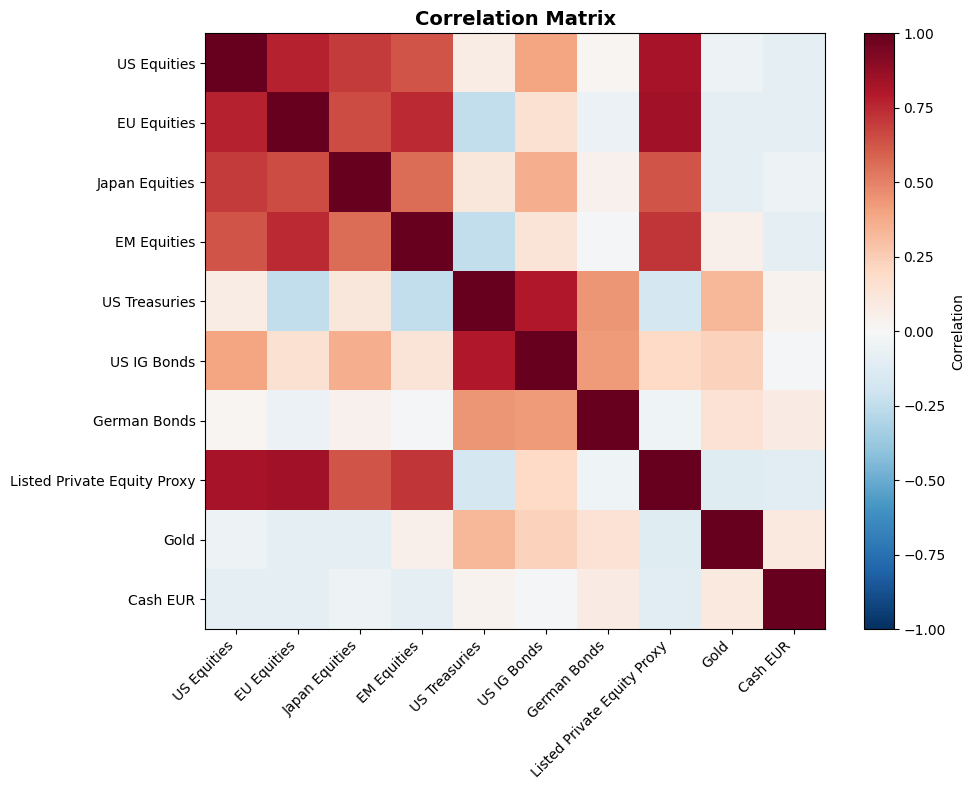

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

heatmap = ax.imshow(
    correlation_matrix_named,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

cbar = plt.colorbar(heatmap)
cbar.set_label("Correlation")

# Set the x-axis tick positions.
# range(len(correlation_matrix_named.columns)) creates one tick position for each asset column.
ax.set_xticks(range(len(correlation_matrix_named.columns)))

# Set the x-axis tick labels using the asset names from the correlation matrix columns.
# rotation=45 tilts the labels so they do not overlap.
# ha="right" aligns the labels to the right for better readability.
ax.set_xticklabels(
    correlation_matrix_named.columns,
    rotation=45,
    ha="right"
)

# Set the y-axis tick positions.
# range(len(correlation_matrix_named.index)) creates one tick position for each asset row.
ax.set_yticks(range(len(correlation_matrix_named.index)))

# Set the y-axis tick labels using the asset names from the correlation matrix index.
ax.set_yticklabels(correlation_matrix_named.index)

ax.set_title("Correlation Matrix", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

**9. ESTIMATE THE ANNUALIZED COVARIANCE MATRIX**

- The covariance matrix measures how asset returns move together.
- It combines volatility and correlation information.
- The covariance matrix is required for portfolio optimization.
- Monthly covariance is annualized by multiplying it by 12.
- This matrix is later used in the Black–Litterman model.

In [ ]:
# Calculate the annualised covariance matrix from monthly returns.
# monthly_returns.cov() calculates the covariance matrix using monthly return data.
# Covariance measures how two assets move together in absolute return terms.
# We multiply by 12 because the data is monthly and we want an annual covariance matrix.
annual_cov_matrix = monthly_returns.cov() * 12

# Create a copy of the covariance matrix.
# We copy it because we want to rename the rows and columns for display,
# without changing the original annual_cov_matrix object.
annual_cov_matrix_named = annual_cov_matrix.copy()

# Rename the row labels from ticker symbols to readable asset-class names.
# Example: "VGK" becomes "EU Equities".
annual_cov_matrix_named.index = [
    asset_names[ticker] for ticker in annual_cov_matrix_named.index
]

# Rename the column labels from ticker symbols to readable asset-class names.
# Example: "GC=F" becomes "Gold".
annual_cov_matrix_named.columns = [
    asset_names[ticker] for ticker in annual_cov_matrix_named.columns
]

# Display the annualised covariance matrix with readable asset names.
display(annual_cov_matrix_named)

,US Equities,EU Equities,Japan Equities,EM Equities,US Treasuries,US IG Bonds,German Bonds,Listed Private Equity Proxy,Gold,Cash EUR
US Equities,0.0211,0.0171,0.0144,0.0153,0.0012,0.0058,0.0001,0.0279,-0.0011,-0.0001
EU Equities,0.0171,0.0235,0.0141,0.0191,-0.0041,0.0023,-0.0004,0.0300,-0.0025,-0.0001
Japan Equities,0.0144,0.0141,0.0200,0.0132,0.0017,0.0052,0.0003,0.0207,-0.0020,-0.0000
EM Equities,0.0153,0.0191,0.0132,0.0279,-0.0044,0.0021,-0.0001,0.0277,0.0014,-0.0001
US Treasuries,0.0012,-0.0041,0.0017,-0.0044,0.0119,0.0088,0.0023,-0.0045,0.0057,0.0000
US IG Bonds,0.0058,0.0023,0.0052,0.0021,0.0088,0.0101,0.0020,0.0046,0.0036,-0.0000
German Bonds,0.0001,-0.0004,0.0003,-0.0001,0.0023,0.0020,0.0022,-0.0005,0.0011,0.0000
Listed Private Equity Proxy,0.0279,0.0300,0.0207,0.0277,-0.0045,0.0046,-0.0005,0.0542,-0.0045,-0.0001
Gold,-0.0011,-0.0025,-0.0020,0.0014,0.0057,0.0036,0.0011,-0.0045,0.0252,0.0001
Cash EUR,-0.0001,-0.0001,-0.0000,-0.0001,0.0000,-0.0000,0.0000,-0.0001,0.0001,0.0000


**10. DEFINE BLACK–LITTERMAN MARKET-CAP PRIOR WEIGHTS**

- These weights are used as the theoretical Black–Litterman prior.
- They are based on the market-cap / benchmark weighting table shared by the group.
- Cash is assigned 0% because cash does not have a market capitalization.
- Cash is still included later through portfolio constraints.
- This addresses the feedback that implied equilibrium returns should be based on market-cap weights, not on the optimized SAA.

In [ ]:
# These weights are based on the market-cap / benchmark weighting table.
# Cash does not have a market cap, so it is set to 0% in the prior.
# Both assets are still included later through portfolio constraints.

market_cap_weights = pd.Series({
    "^SP500TR": 0.42725,   # US Equities
    "VGK": 0.02911,        # European Equities
    "EWJ": 0.04717,        # Japanese Equities
    "EEM": 0.02045,        # Emerging Market Equities
    "PSP": 0.06064,        # Listed Private Equity Proxy
    "DE_BONDS": 0.01450,   # German Government Bonds
    "IEF": 0.23653,        # US Treasury Bonds
    "LQD": 0.10979,        # Investment Grade Credit
    "GC=F": 0.05455,       # Gold
    "XEON.DE": 0.00000,    # Cash EUR
})

# Reorder to match the model asset order
market_cap_weights = market_cap_weights.reindex(final_tickers).fillna(0)

# Check that weights sum to 100%
assert np.isclose(market_cap_weights.sum(), 1.0), "Market-cap weights must sum to 100%."

market_cap_table = market_cap_weights.to_frame("Market-Cap Prior Weight")
market_cap_table.index = [asset_names[ticker] for ticker in market_cap_table.index]

display(market_cap_table)
print("Total market-cap prior weight:", round(market_cap_weights.sum(), 4))

,Market-Cap Prior Weight
US Equities,0.4273
EU Equities,0.0291
Japan Equities,0.0472
EM Equities,0.0204
US Treasuries,0.2365
US IG Bonds,0.1098
German Bonds,0.0145
Listed Private Equity Proxy,0.0606
Gold,0.0546
Cash EUR,0.0000


Total market-cap prior weight: 1.0


**VISUALIZATION: BLACK–LITTERMAN MARKET-CAP PRIOR WEIGHTS**

- This chart shows the market-cap / benchmark prior used for the Black–Litterman model.
- The prior is concentrated because market-cap weighting gives more weight to the largest asset classes.
- Later constraints prevent the final portfolio from becoming unrealistic for the family office.

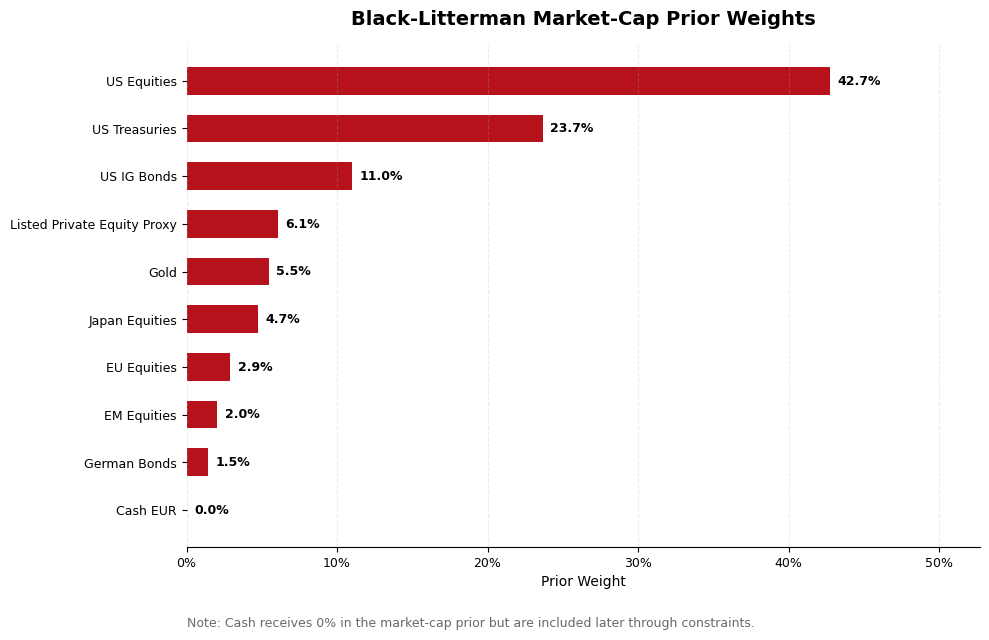

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))

market_cap_plot = market_cap_table["Market-Cap Prior Weight"].sort_values(ascending=True)

bars = ax.barh(
    market_cap_plot.index,
    market_cap_plot.values,
    color="#b5121b",
    height=0.58
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1%}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_title(
    "Black-Litterman Market-Cap Prior Weights",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Prior Weight", fontsize=10)
ax.set_ylabel("")
ax.set_xlim(0, market_cap_plot.max() + 0.10)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)

ax.text(
    0,
    -0.16,
    "Note: Cash receives 0% in the market-cap prior but are included later through constraints.",
    transform=ax.transAxes,
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.show()

**11. SET THE RISK-FREE RATE AND CALCULATE RISK AVERSION**

- The risk-free rate is used as the baseline return.
- The risk-aversion coefficient is calculated from the market-cap prior portfolio return and variance.
- The formula is: risk aversion = (benchmark return - risk-free rate) / benchmark variance.
- This avoids hardcoding the risk-aversion coefficient without explanation.
- The risk-aversion coefficient is later used to calculate implied equilibrium returns.

In [ ]:
#risk_free_rate = 0.0231
# Use XEON.DE as the EUR risk-free-rate proxy
xeon_monthly_returns = monthly_returns["XEON.DE"].dropna()

# Remove the latest observation if it belongs to the current, incomplete month
current_month = pd.Timestamp.today().to_period("M")

if xeon_monthly_returns.index[-1].to_period("M") == current_month:
    xeon_monthly_returns = xeon_monthly_returns.iloc[:-1]

# Annualise the last complete monthly XEON return
last_xeon_monthly_return = xeon_monthly_returns.iloc[-1]

risk_free_rate = (1 + last_xeon_monthly_return) ** 12 - 1

# Calculate benchmark return and variance from market-cap prior weights
benchmark_return = np.dot(
    market_cap_weights,
    annualised_returns.loc[market_cap_weights.index]
)

benchmark_variance = np.dot(
    market_cap_weights,
    np.dot(
        annual_cov_matrix.loc[
            market_cap_weights.index,
            market_cap_weights.index
        ],
        market_cap_weights
    )
)

risk_aversion = (benchmark_return - risk_free_rate) / benchmark_variance

print("Benchmark return:", round(benchmark_return, 4))
print("Benchmark variance:", round(benchmark_variance, 4))
print("Risk-free rate:", risk_free_rate)
print("Risk-aversion coefficient:", round(risk_aversion, 4))

Benchmark return: 0.092
Benchmark variance: 0.0094
Risk-free rate: 0.023302041165678133
Risk-aversion coefficient: 7.3199


 **12. CALCULATE IMPLIED EQUILIBRIUM RETURNS**

- Implied equilibrium returns are calculated from the market-cap prior weights.
- These returns represent the neutral starting point of the Black–Litterman model.
- They are not based directly on historical average returns.
- This follows the Black–Litterman logic more correctly than using historical mean returns directly.

In [ ]:
equilibrium_returns = market_implied_prior_returns(
    market_caps=market_cap_weights,
    risk_aversion=risk_aversion,
    cov_matrix=annual_cov_matrix,
    risk_free_rate=risk_free_rate
)

equilibrium_table = equilibrium_returns.to_frame("Implied Equilibrium Return")
equilibrium_table.index = [asset_names[ticker] for ticker in equilibrium_table.index]

display(equilibrium_table)

,Implied Equilibrium Return
US Equities,0.1188
EU Equities,0.0965
Japan Equities,0.0960
EM Equities,0.0909
US Treasuries,0.0542
US IG Bonds,0.0711
German Bonds,0.0297
Listed Private Equity Proxy,0.1464
Gold,0.0399
Cash EUR,0.0231


**VISUALIZATION: IMPLIED EQUILIBRIUM RETURNS**

- This chart shows the return estimates implied by the Black–Litterman market-cap prior weights.
- These are not yet the final Black–Litterman returns.
- They are the neutral starting point before adding Deutsche Bank-inspired views.

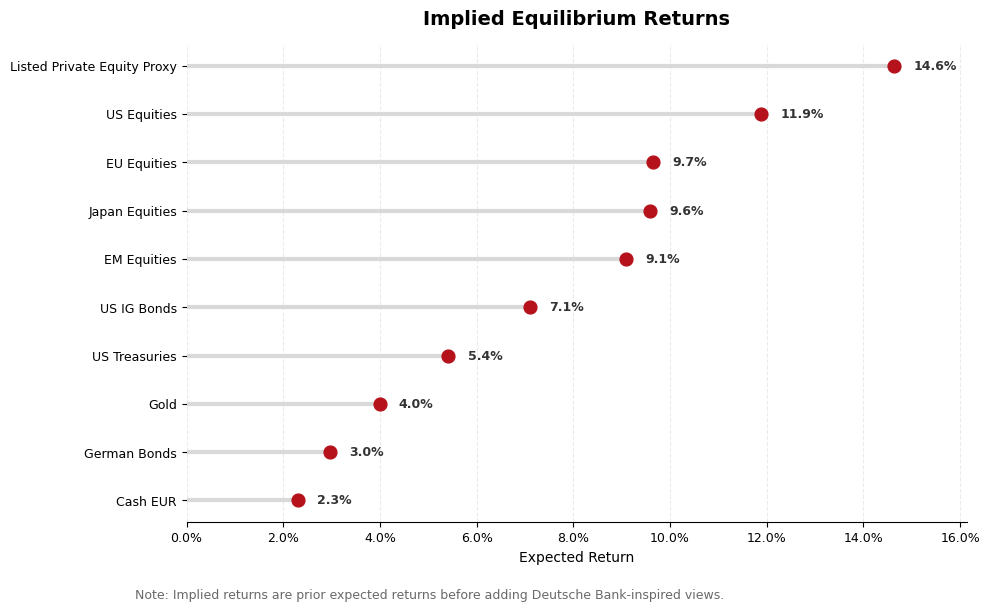

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))

equilibrium_plot = equilibrium_table["Implied Equilibrium Return"].sort_values()
y_pos = np.arange(len(equilibrium_plot))

ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=equilibrium_plot.values,
    color="#d9d9d9",
    linewidth=3
)

ax.scatter(
    equilibrium_plot.values,
    y_pos,
    color="#b5121b",
    s=85,
    zorder=3
)

for i, value in enumerate(equilibrium_plot.values):
    ax.text(
        value + 0.004,
        i,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
        color="#333333"
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(equilibrium_plot.index)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_title(
    "Implied Equilibrium Returns",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Expected Return", fontsize=10)
ax.set_ylabel("")
ax.set_xlim(0, equilibrium_plot.max() + 0.015)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)

fig.text(
    0.14,
    0.02,
    "Note: Implied returns are prior expected returns before adding Deutsche Bank-inspired views.",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

**13. BUILD OPTIMIZED STRATEGIC ASSET ALLOCATION USING IMPLIED RETURNS**

- The optimized SAA is calculated after the implied equilibrium returns.
- This avoids relying directly on historical average returns.
- The optimizer uses implied equilibrium returns and the annualized covariance matrix.
- Portfolio restrictions are added to avoid unrealistic concentration.
- Minimum allocation constraints are included so important family-office asset classes do not become zero.

In [ ]:
# Keep ticker order consistent across returns, covariance matrix and weights
tickers_order = list(equilibrium_returns.index)

# Individual asset indices
cash_idx = tickers_order.index("XEON.DE")
em_idx = tickers_order.index("EEM")
private_equity_idx = tickers_order.index("PSP")
gold_idx = tickers_order.index("GC=F")

us_equity_idx = tickers_order.index("^SP500TR")
eu_equity_idx = tickers_order.index("VGK")
japan_equity_idx = tickers_order.index("EWJ")
us_ig_bond_idx = tickers_order.index("LQD")

us_treasury_idx = tickers_order.index("IEF")
german_bond_idx = tickers_order.index("DE_BONDS")

# Group indices
equity_indices = [
    us_equity_idx,
    eu_equity_idx,
    japan_equity_idx,
    em_idx
]

bond_indices = [
    us_treasury_idx,
    us_ig_bond_idx,
    german_bond_idx
]

# Create optimizer using implied equilibrium returns, not historical average returns
ef_saa = EfficientFrontier(
    expected_returns=equilibrium_returns,
    cov_matrix=annual_cov_matrix,
    weight_bounds=(0.00, 0.25)   # no single asset can exceed 25%
)

# Practical family-office restrictions
ef_saa.add_constraint(lambda w: w[cash_idx] >= 0.05)
ef_saa.add_constraint(lambda w: w[cash_idx] <= 0.10)

ef_saa.add_constraint(lambda w: w[em_idx] >= 0.02)
ef_saa.add_constraint(lambda w: w[em_idx] <= 0.10)

ef_saa.add_constraint(lambda w: w[private_equity_idx] >= 0.03)
ef_saa.add_constraint(lambda w: w[private_equity_idx] <= 0.10)

ef_saa.add_constraint(lambda w: w[gold_idx] >= 0.03)
ef_saa.add_constraint(lambda w: w[gold_idx] <= 0.10)

ef_saa.add_constraint(lambda w: w[eu_equity_idx] >= 0.03)
ef_saa.add_constraint(lambda w: w[japan_equity_idx] >= 0.03)
ef_saa.add_constraint(lambda w: w[us_ig_bond_idx] >= 0.08)

ef_saa.add_constraint(lambda w: sum(w[i] for i in equity_indices) >= 0.30)
ef_saa.add_constraint(lambda w: sum(w[i] for i in equity_indices) <= 0.50)

ef_saa.add_constraint(lambda w: sum(w[i] for i in bond_indices) >= 0.25)

# Optimization objective
ef_saa.max_sharpe(risk_free_rate=risk_free_rate)

optimized_saa_weights = pd.Series(ef_saa.clean_weights())
optimized_saa_weights = optimized_saa_weights.reindex(tickers_order).fillna(0)

optimized_saa_table = optimized_saa_weights.to_frame("Optimized SAA Weight")
optimized_saa_table.index = [asset_names[ticker] for ticker in optimized_saa_table.index]

display(optimized_saa_table)

# Portfolio performance
saa_expected_return, saa_volatility, saa_sharpe = ef_saa.portfolio_performance(
    risk_free_rate=risk_free_rate
)

saa_performance = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        saa_expected_return,
        saa_volatility,
        saa_sharpe
    ]
})

display(saa_performance)

,Optimized SAA Weight
US Equities,0.2500
EU Equities,0.0575
Japan Equities,0.0593
EM Equities,0.0226
US Treasuries,0.2317
US IG Bonds,0.0951
German Bonds,0.0545
Listed Private Equity Proxy,0.0828
Gold,0.0465
Cash EUR,0.1000


,Metric,Value
0,Expected Annual Return,0.0802
1,Annual Volatility,0.0806
2,Sharpe Ratio,0.7059


**14. DEFINE DEUTSCHE BANK-INSPIRED MARKET VIEWS**

- Market views are forward-looking return assumptions.
- These views are based on the Deutsche Bank 2026 annual outlook.
- The views are not exact forecasts for the selected ETFs.
- They translate the Deutsche Bank macro and asset-class outlook into model inputs.
- These views will adjust the implied equilibrium returns in the Black–Litterman model.

In [ ]:
bl_assets = list(equilibrium_returns.index)

relative_views = pd.DataFrame({
    "View": [
        "Gold outperforms Cash EUR",
        "US Equities outperform EU Equities",
        "US IG Bonds outperform German Bonds"
    ],
    "Outperforming Asset": [
        "GC=F",
        "^SP500TR",
        "LQD"
    ],
    "Underperforming Asset": [
        "XEON.DE",
        "VGK",
        "DE_BONDS"
    ],
    "Expected Outperformance": [
        0.040,   # Gold expected to outperform cash by 4.0%
        0.010,   # US equities expected to outperform EU equities by 1.0%
        0.015   # US IG bonds expected to outperform German bonds by 1.5%
    ]
})

# Create P matrix
P = pd.DataFrame(
    0.0,
    index=relative_views["View"],
    columns=bl_assets
)

for _, row in relative_views.iterrows():
    P.loc[row["View"], row["Outperforming Asset"]] = 1
    P.loc[row["View"], row["Underperforming Asset"]] = -1

# Create Q vector
Q = relative_views.set_index("View")["Expected Outperformance"]

display(relative_views)
display(P)
display(Q.to_frame("Q: Expected Outperformance"))

,View,Outperforming Asset,Underperforming Asset,Expected Outperformance
0,Gold outperforms Cash EUR,GC=F,XEON.DE,0.0400
1,US Equities outperform EU Equities,^SP500TR,VGK,0.0100
2,US IG Bonds outperform German Bonds,LQD,DE_BONDS,0.0150


,^SP500TR,VGK,EWJ,EEM,IEF,LQD,DE_BONDS,PSP,GC=F,XEON.DE
View,,,,,,,,,,
Gold outperforms Cash EUR,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,-1.0000
US Equities outperform EU Equities,1.0000,-1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
US IG Bonds outperform German Bonds,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,-1.0000,0.0000,0.0000,0.0000


,Q: Expected Outperformance
View,
Gold outperforms Cash EUR,0.0400
US Equities outperform EU Equities,0.0100
US IG Bonds outperform German Bonds,0.0150


**15. DEFINE VIEW CONFIDENCE LEVELS**

- View confidence levels show how strongly the model should trust each Deutsche Bank-inspired market view.
- A higher confidence level gives the view more influence in the Black–Litterman model.
- A lower confidence level means the model stays closer to the implied equilibrium returns.
- The confidence levels are subjective assumptions based on how clearly the Deutsche Bank outlook supports each view.
- These confidence levels are used with Idzorek’s method in the Black–Litterman model.

In [ ]:
view_confidences = pd.Series({
    "Gold outperforms Cash EUR": 0.70,
    "US Equities outperform EU Equities": 0.60,
    "US IG Bonds outperform German Bonds": 0.65
})

view_confidences = view_confidences.loc[P.index]

confidence_table = pd.DataFrame({
    "Expected Outperformance": Q,
    "View Confidence": view_confidences
})

display(confidence_table)

assert ((view_confidences >= 0) & (view_confidences <= 1)).all(), "Confidence levels must be between 0 and 1."
print("Number of relative views:", len(Q))
print("Number of confidence levels:", len(view_confidences))

,Expected Outperformance,View Confidence
View,,
Gold outperforms Cash EUR,0.0400,0.7000
US Equities outperform EU Equities,0.0100,0.6000
US IG Bonds outperform German Bonds,0.0150,0.6500


Number of relative views: 3
Number of confidence levels: 3


**16. CALCULATE BLACK–LITTERMAN POSTERIOR RETURNS**

- Posterior returns combine the implied equilibrium returns with the Deutsche Bank-inspired market views.
- The implied equilibrium returns are used as the neutral starting point.
- The view confidence levels control how strongly the market views affect the final result.
- Idzorek’s method is used to convert the confidence levels into view uncertainty.
- These posterior returns will later be used for the final tactical portfolio optimization.

In [ ]:
assert "equilibrium_returns" in globals(), "Run Step 13 first."
assert "P" in globals(), "Run Step 16 first."
assert "Q" in globals(), "Run Step 16 first."
assert "view_confidences" in globals(), "Run Step 17 first."

tau = 0.05

bl_model = BlackLittermanModel(
    cov_matrix=annual_cov_matrix.loc[bl_assets, bl_assets],
    pi=equilibrium_returns.loc[bl_assets],
    P=P.values,
    Q=Q.values,
    omega="idzorek",
    view_confidences=view_confidences.values,
    tau=tau
)

posterior_returns = bl_model.bl_returns()
posterior_cov_matrix = bl_model.bl_cov()

posterior_comparison = pd.DataFrame({
    "Implied Equilibrium Return": equilibrium_returns.loc[bl_assets],
    "Black-Litterman Posterior Return": posterior_returns,
    "Difference": posterior_returns - equilibrium_returns.loc[bl_assets]
})

posterior_comparison.index = [
    asset_names[ticker] for ticker in posterior_comparison.index
]

display(posterior_comparison)

,Implied Equilibrium Return,Black-Litterman Posterior Return,Difference
US Equities,0.1188,0.1043,-0.0145
EU Equities,0.0965,0.0914,-0.0051
Japan Equities,0.0960,0.0837,-0.0123
EM Equities,0.0909,0.0889,-0.0021
US Treasuries,0.0542,0.0427,-0.0114
US IG Bonds,0.0711,0.0553,-0.0158
German Bonds,0.0297,0.0308,0.0011
Listed Private Equity Proxy,0.1464,0.1328,-0.0136
Gold,0.0399,0.0544,0.0145
Cash EUR,0.0231,0.0232,0.0001


**17. COMPARE IMPLIED EQUILIBRIUM RETURNS AND POSTERIOR RETURNS**

- This step compares the neutral implied equilibrium returns with the Black–Litterman posterior returns.
- Implied equilibrium returns are based on the market-cap prior weights.
- Posterior returns include the Deutsche Bank-inspired market views and confidence levels.
- The difference shows how much the views changed the expected return of each asset.

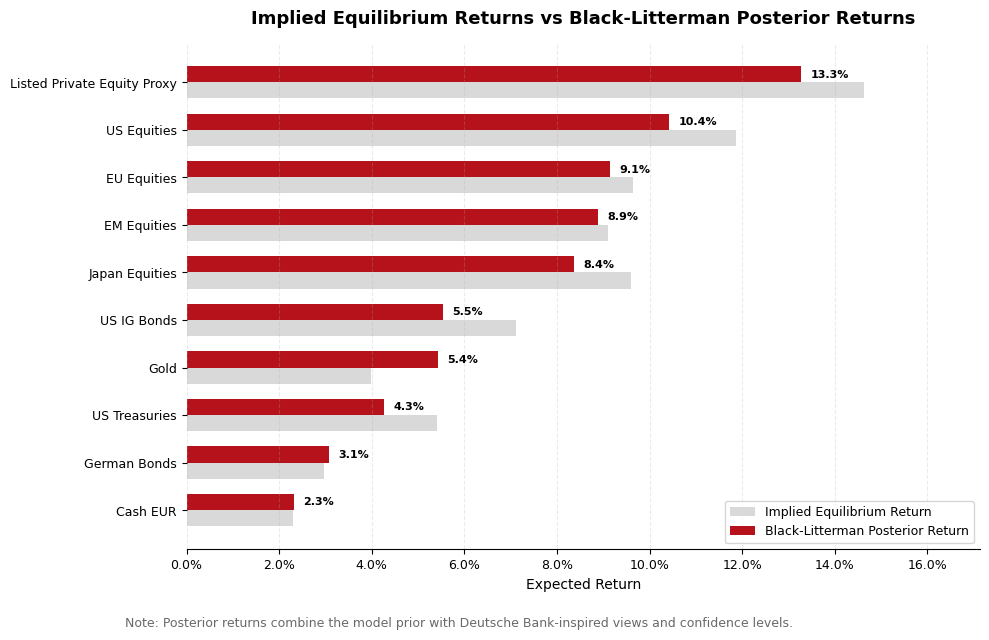

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.8))

plot_data = posterior_comparison[
    ["Implied Equilibrium Return", "Black-Litterman Posterior Return"]
].sort_values("Black-Litterman Posterior Return")

y_pos = np.arange(len(plot_data))
bar_height = 0.34

ax.barh(
    y_pos - bar_height / 2,
    plot_data["Implied Equilibrium Return"],
    height=bar_height,
    label="Implied Equilibrium Return",
    color="#d9d9d9"
)

ax.barh(
    y_pos + bar_height / 2,
    plot_data["Black-Litterman Posterior Return"],
    height=bar_height,
    label="Black-Litterman Posterior Return",
    color="#b5121b"
)

for i, value in enumerate(plot_data["Black-Litterman Posterior Return"]):
    ax.text(
        value + 0.002,
        i + bar_height / 2,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold"
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data.index)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_title(
    "Implied Equilibrium Returns vs Black-Litterman Posterior Returns",
    fontsize=13,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Expected Return")
ax.set_ylabel("")
ax.set_xlim(0, max(plot_data.max()) + 0.025)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)

fig.text(
    0.13,
    0.02,
    "Note: Posterior returns combine the model prior with Deutsche Bank-inspired views and confidence levels.",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

**18. DEFINE TACTICAL PORTFOLIO CONSTRAINTS**

- Portfolio constraints are used to avoid unrealistic optimizer results.
- Without constraints, the optimizer may allocate too much weight to only a few assets.
- The constraints reflect the family office’s conservative but growth-oriented profile.
- Cash is required to stay between 5% and 10%.
- Minimum allocations are included for selected asset classes to keep the portfolio diversified.

In [ ]:
# Check that all required inputs are available
assert "posterior_returns" in globals(), "Run Step 18 first: posterior_returns is not defined."
assert "posterior_cov_matrix" in globals(), "Run Step 18 first: posterior_cov_matrix is not defined."
assert "optimized_saa_weights" in globals(), "Run the SAA optimization first."

# Asset order used by the tactical optimizer
optimizer_tickers = list(posterior_returns.index)

# Align the strategic allocation with the tactical optimizer
saa_anchor_weights = (
    optimized_saa_weights
    .reindex(optimizer_tickers)
    .fillna(0.0)
)

# Individual asset indices
cash_idx = optimizer_tickers.index("XEON.DE")
em_idx = optimizer_tickers.index("EEM")
private_equity_idx = optimizer_tickers.index("PSP")
gold_idx = optimizer_tickers.index("GC=F")

us_equity_idx = optimizer_tickers.index("^SP500TR")
eu_equity_idx = optimizer_tickers.index("VGK")
japan_equity_idx = optimizer_tickers.index("EWJ")

us_treasury_idx = optimizer_tickers.index("IEF")
us_ig_bond_idx = optimizer_tickers.index("LQD")
german_bond_idx = optimizer_tickers.index("DE_BONDS")

# Group indices
equity_indices = [
    us_equity_idx,
    eu_equity_idx,
    japan_equity_idx,
    em_idx
]

bond_indices = [
    us_treasury_idx,
    us_ig_bond_idx,
    german_bond_idx
]

# Maximum tactical deviation from the strategic allocation
max_tactical_deviation = 0.03

# Asset-specific tactical bounds around the SAA
tactical_bounds = []

for ticker in optimizer_tickers:
    saa_weight = saa_anchor_weights.loc[ticker]

    lower_bound = max(
        0.00,
        saa_weight - max_tactical_deviation
    )

    upper_bound = min(
        0.25,
        saa_weight + max_tactical_deviation
    )

    tactical_bounds.append(
        (lower_bound, upper_bound)
    )

# Display the tactical allocation framework
constraint_summary = pd.DataFrame({
    "Constraint": [
        "Maximum absolute tactical deviation per asset",
        "Maximum weight per single asset",
        "Minimum cash allocation",
        "Maximum cash allocation",
        "Minimum emerging-market equity allocation",
        "Maximum emerging-market equity allocation",
        "Minimum Listed Private Equity proxy allocation",
        "Maximum Listed Private Equity proxy allocation",
        "Minimum gold allocation",
        "Maximum gold allocation",
        "Minimum EU equity allocation",
        "Minimum Japan equity allocation",
        "Minimum US IG bond allocation",
        "Minimum total equity allocation",
        "Maximum total equity allocation",
        "Minimum total bond allocation"
    ],
    "Value": [
        "3 percentage points",
        "25%",
        "5%",
        "10%",
        "2%",
        "10%",
        "3%",
        "10%",
        "3%",
        "10%",
        "3%",
        "3%",
        "8%",
        "30%",
        "50%",
        "25%"
    ]
})

display(constraint_summary)

# Display asset-specific tactical ranges
tactical_range_table = pd.DataFrame(
    tactical_bounds,
    index=optimizer_tickers,
    columns=[
        "Minimum Tactical Weight",
        "Maximum Tactical Weight"
    ]
)

tactical_range_table.insert(
    0,
    "Strategic Allocation",
    saa_anchor_weights
)

tactical_range_table.index = [
    asset_names[ticker]
    for ticker in tactical_range_table.index
]

display(tactical_range_table)

,Constraint,Value
0,Maximum absolute tactical deviation per asset,3 percentage points
1,Maximum weight per single asset,25%
2,Minimum cash allocation,5%
3,Maximum cash allocation,10%
4,Minimum emerging-market equity allocation,2%
5,Maximum emerging-market equity allocation,10%
6,Minimum Listed Private Equity proxy allocation,3%
7,Maximum Listed Private Equity proxy allocation,10%
8,Minimum gold allocation,3%
9,Maximum gold allocation,10%


,Strategic Allocation,Minimum Tactical Weight,Maximum Tactical Weight
US Equities,0.2500,0.2200,0.2500
EU Equities,0.0575,0.0275,0.0875
Japan Equities,0.0593,0.0293,0.0893
EM Equities,0.0226,0.0000,0.0526
US Treasuries,0.2317,0.2017,0.2500
US IG Bonds,0.0951,0.0651,0.1251
German Bonds,0.0545,0.0245,0.0845
Listed Private Equity Proxy,0.0828,0.0528,0.1128
Gold,0.0465,0.0165,0.0765
Cash EUR,0.1000,0.0700,0.1300


**19. OPTIMIZE THE BLACK–LITTERMAN TACTICAL PORTFOLIO**

- The Black–Litterman posterior returns incorporate the one-year Deutsche Bank-inspired relative views.
- The optimized SAA is used as the neutral long-term portfolio anchor.
- Each asset may deviate by a maximum of three percentage points from its strategic weight.
- The tactical optimizer therefore creates controlled active positions rather than reconstructing the entire portfolio.
- The original family-office constraints remain in place to preserve the client’s liquidity, diversification and risk requirements.
- The tactical portfolio is optimized under the one-year Black–Litterman assumptions.

In [ ]:
# Check that required inputs are available
assert "posterior_returns" in globals(), "Run Step 18 first: posterior_returns is not defined."
assert "posterior_cov_matrix" in globals(), "Run Step 18 first: posterior_cov_matrix is not defined."
assert "risk_free_rate" in globals(), "Run Step 12 first: risk_free_rate is not defined."
assert "optimizer_tickers" in globals(), "Run Step 20 first: optimizer_tickers is not defined."
assert "tactical_bounds" in globals(), "Run Step 20 first: tactical_bounds is not defined."
assert "saa_anchor_weights" in globals(), "Run Step 20 first: SAA anchor weights are not defined."

# Create tactical optimizer using Black-Litterman posterior inputs
#
# The weight bounds are centred around the SAA.
# Therefore, the optimizer produces tactical deviations instead of
# constructing a completely new strategic portfolio.
ef_tactical = EfficientFrontier(
    expected_returns=posterior_returns.reindex(optimizer_tickers),
    cov_matrix=posterior_cov_matrix.loc[
        optimizer_tickers,
        optimizer_tickers
    ],
    weight_bounds=tactical_bounds
)

# Retain the client's strategic portfolio restrictions
ef_tactical.add_constraint(
    lambda w: w[cash_idx] >= 0.05
)

ef_tactical.add_constraint(
    lambda w: w[cash_idx] <= 0.10
)

ef_tactical.add_constraint(
    lambda w: w[em_idx] >= 0.02
)

ef_tactical.add_constraint(
    lambda w: w[em_idx] <= 0.10
)

ef_tactical.add_constraint(
    lambda w: w[private_equity_idx] >= 0.03
)

ef_tactical.add_constraint(
    lambda w: w[private_equity_idx] <= 0.10
)

ef_tactical.add_constraint(
    lambda w: w[gold_idx] >= 0.03
)

ef_tactical.add_constraint(
    lambda w: w[gold_idx] <= 0.10
)

ef_tactical.add_constraint(
    lambda w: w[eu_equity_idx] >= 0.03
)

ef_tactical.add_constraint(
    lambda w: w[japan_equity_idx] >= 0.03
)

ef_tactical.add_constraint(
    lambda w: w[us_ig_bond_idx] >= 0.08
)

ef_tactical.add_constraint(
    lambda w: sum(
        w[i] for i in equity_indices
    ) >= 0.30
)

ef_tactical.add_constraint(
    lambda w: sum(
        w[i] for i in equity_indices
    ) <= 0.50
)

ef_tactical.add_constraint(
    lambda w: sum(
        w[i] for i in bond_indices
    ) >= 0.25
)

# Optimize the tactical allocation
ef_tactical.max_sharpe(
    risk_free_rate=risk_free_rate
)

# Store final tactical weights
tactical_weights = pd.Series(
    ef_tactical.clean_weights()
)

tactical_weights = (
    tactical_weights
    .reindex(optimizer_tickers)
    .fillna(0.0)
)

# Calculate active tactical positions relative to the SAA
tactical_changes = (
    tactical_weights
    - saa_anchor_weights
)

# Create tactical allocation table
tactical_table = pd.DataFrame({
    "SAA Weight": saa_anchor_weights,
    "Black-Litterman TAA Weight": tactical_weights,
    "Tactical Change": tactical_changes
})

tactical_table.index = [
    asset_names[ticker]
    for ticker in tactical_table.index
]

display(tactical_table)

# Verify that tactical deviations remain within the limit
maximum_realised_deviation = tactical_changes.abs().max()

print(
    "Maximum realised tactical deviation:",
    f"{maximum_realised_deviation:.2%}"
)

assert (
    maximum_realised_deviation
    <= max_tactical_deviation + 1e-6
), "At least one tactical position exceeds the allowed deviation."

# Tactical portfolio performance under BL assumptions
tactical_expected_return, tactical_volatility, tactical_sharpe = (
    ef_tactical.portfolio_performance(
        risk_free_rate=risk_free_rate
    )
)

tactical_performance = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        tactical_expected_return,
        tactical_volatility,
        tactical_sharpe
    ]
})

display(tactical_performance)

,SAA Weight,Black-Litterman TAA Weight,Tactical Change
US Equities,0.2500,0.2500,0.0000
EU Equities,0.0575,0.0875,0.0300
Japan Equities,0.0593,0.0300,-0.0293
EM Equities,0.0226,0.0526,0.0300
US Treasuries,0.2317,0.2017,-0.0300
US IG Bonds,0.0951,0.0800,-0.0151
German Bonds,0.0545,0.0845,0.0300
Listed Private Equity Proxy,0.0828,0.0673,-0.0156
Gold,0.0465,0.0765,0.0300
Cash EUR,0.1000,0.0700,-0.0300


Maximum realised tactical deviation: 3.00%


,Metric,Value
0,Expected Annual Return,0.0716
1,Annual Volatility,0.0815
2,Sharpe Ratio,0.5925


**20. COMPARE OPTIMIZED SAA AND BLACK–LITTERMAN TAA**

- This step compares the optimized strategic asset allocation with the final Black–Litterman tactical allocation.
- The optimized SAA represents the longer-term allocation based on implied returns, covariance and restrictions.
- The Black–Litterman TAA includes the Deutsche Bank-inspired market views.
- The difference shows how the tactical portfolio shifts away from the strategic allocation.

In [ ]:
# Align both portfolios in the same ticker order
saa_weights_aligned = optimized_saa_weights.reindex(optimizer_tickers).fillna(0)
tactical_weights_aligned = tactical_weights.reindex(optimizer_tickers).fillna(0)

# Create comparison table
saa_vs_tactical = pd.DataFrame({
    "Optimized SAA Weight": saa_weights_aligned,
    "Black-Litterman TAA Weight": tactical_weights_aligned
})

saa_vs_tactical["Tactical Change"] = (
    saa_vs_tactical["Black-Litterman TAA Weight"]
    - saa_vs_tactical["Optimized SAA Weight"]
)

saa_vs_tactical.index = [
    asset_names[ticker] for ticker in saa_vs_tactical.index
]

display(saa_vs_tactical)

,Optimized SAA Weight,Black-Litterman TAA Weight,Tactical Change
US Equities,0.2500,0.2500,0.0000
EU Equities,0.0575,0.0875,0.0300
Japan Equities,0.0593,0.0300,-0.0293
EM Equities,0.0226,0.0526,0.0300
US Treasuries,0.2317,0.2017,-0.0300
US IG Bonds,0.0951,0.0800,-0.0151
German Bonds,0.0545,0.0845,0.0300
Listed Private Equity Proxy,0.0828,0.0673,-0.0156
Gold,0.0465,0.0765,0.0300
Cash EUR,0.1000,0.0700,-0.0300


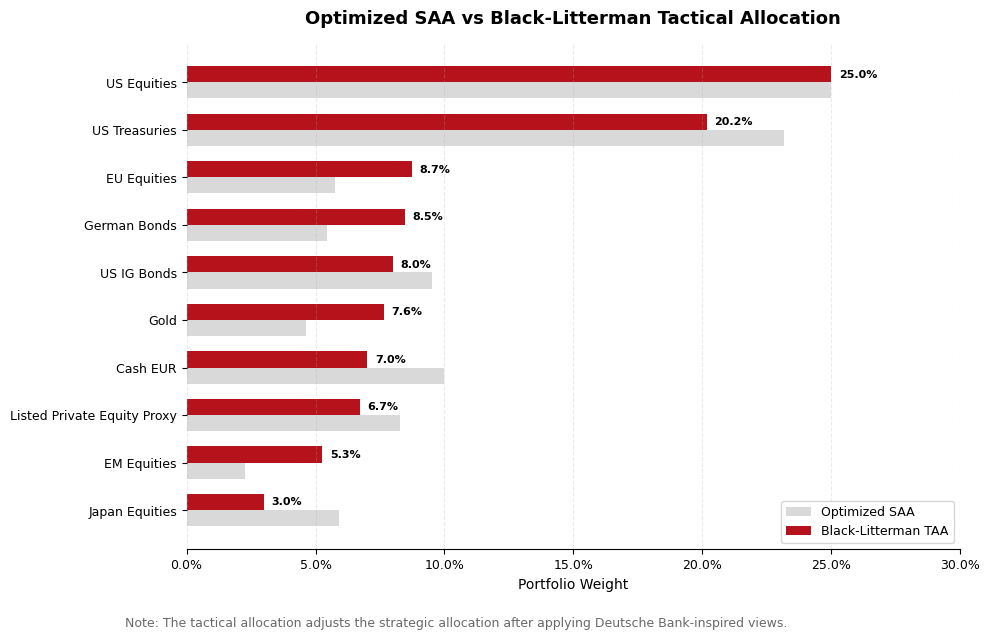

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.8))

plot_data = saa_vs_tactical[
    ["Optimized SAA Weight", "Black-Litterman TAA Weight"]
].sort_values("Black-Litterman TAA Weight")

y_pos = np.arange(len(plot_data))
bar_height = 0.34

ax.barh(
    y_pos - bar_height / 2,
    plot_data["Optimized SAA Weight"],
    height=bar_height,
    label="Optimized SAA",
    color="#d9d9d9"
)

ax.barh(
    y_pos + bar_height / 2,
    plot_data["Black-Litterman TAA Weight"],
    height=bar_height,
    label="Black-Litterman TAA",
    color="#b5121b"
)

for i, value in enumerate(plot_data["Black-Litterman TAA Weight"]):
    ax.text(
        value + 0.003,
        i + bar_height / 2,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold"
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data.index)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_title(
    "Optimized SAA vs Black-Litterman Tactical Allocation",
    fontsize=13,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Portfolio Weight")
ax.set_ylabel("")
ax.set_xlim(0, max(plot_data.max()) + 0.05)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)

fig.text(
    0.13,
    0.02,
    "Note: The tactical allocation adjusts the strategic allocation after applying Deutsche Bank-inspired views.",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

**21. CALCULATE FINAL PORTFOLIO STATISTICS**

- This step calculates the final performance statistics of the Black–Litterman tactical portfolio.
- Expected return shows the model-based annual return expectation.
- Volatility shows the annual risk level of the portfolio.
- The Sharpe ratio measures return per unit of risk.
- The optimized SAA and Black–Litterman TAA are compared using the same posterior return assumptions.

In [ ]:
# Helper function for portfolio statistics
def calculate_portfolio_statistics(weights, expected_returns, covariance_matrix, risk_free_rate):
    weights = weights.reindex(expected_returns.index).fillna(0)

    portfolio_return = np.dot(weights, expected_returns)

    portfolio_variance = np.dot(
        weights,
        np.dot(covariance_matrix.loc[expected_returns.index, expected_returns.index], weights)
    )

    portfolio_volatility = np.sqrt(portfolio_variance)
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    return portfolio_return, portfolio_volatility, sharpe_ratio


# Align weights
optimized_saa_weights_aligned = optimized_saa_weights.reindex(posterior_returns.index).fillna(0)
tactical_weights_aligned = tactical_weights.reindex(posterior_returns.index).fillna(0)

# Calculate optimized SAA statistics using posterior assumptions
saa_return, saa_volatility, saa_sharpe = calculate_portfolio_statistics(
    optimized_saa_weights_aligned,
    posterior_returns,
    posterior_cov_matrix,
    risk_free_rate
)

# Calculate Black-Litterman TAA statistics
taa_return, taa_volatility, taa_sharpe = calculate_portfolio_statistics(
    tactical_weights_aligned,
    posterior_returns,
    posterior_cov_matrix,
    risk_free_rate
)

# Create final statistics table
final_statistics = pd.DataFrame({
    "Portfolio": [
        "Optimized SAA",
        "Black-Litterman TAA"
    ],
    "Expected Annual Return": [
        saa_return,
        taa_return
    ],
    "Annual Volatility": [
        saa_volatility,
        taa_volatility
    ],
    "Sharpe Ratio": [
        saa_sharpe,
        taa_sharpe
    ]
})

display(final_statistics)

final_statistics_formatted = final_statistics.copy()
final_statistics_formatted["Expected Annual Return"] = final_statistics_formatted["Expected Annual Return"].map("{:.2%}".format)
final_statistics_formatted["Annual Volatility"] = final_statistics_formatted["Annual Volatility"].map("{:.2%}".format)
final_statistics_formatted["Sharpe Ratio"] = final_statistics_formatted["Sharpe Ratio"].map("{:.2f}".format)

display(final_statistics_formatted)

,Portfolio,Expected Annual Return,Annual Volatility,Sharpe Ratio
0,Optimized SAA,0.0710,0.0820,0.5811
1,Black-Litterman TAA,0.0716,0.0815,0.5925


,Portfolio,Expected Annual Return,Annual Volatility,Sharpe Ratio
0,Optimized SAA,7.10%,8.20%,0.58
1,Black-Litterman TAA,7.16%,8.15%,0.59


**VISUALIZE FINAL PORTFOLIO RESULTS**

- This section visualizes the final Black–Litterman tactical allocation.
- The first chart shows how capital is allocated across asset classes.
- The second chart compares the optimized SAA and the Black–Litterman TAA using return and volatility.
- The third chart compares risk-adjusted performance using the Sharpe ratio.

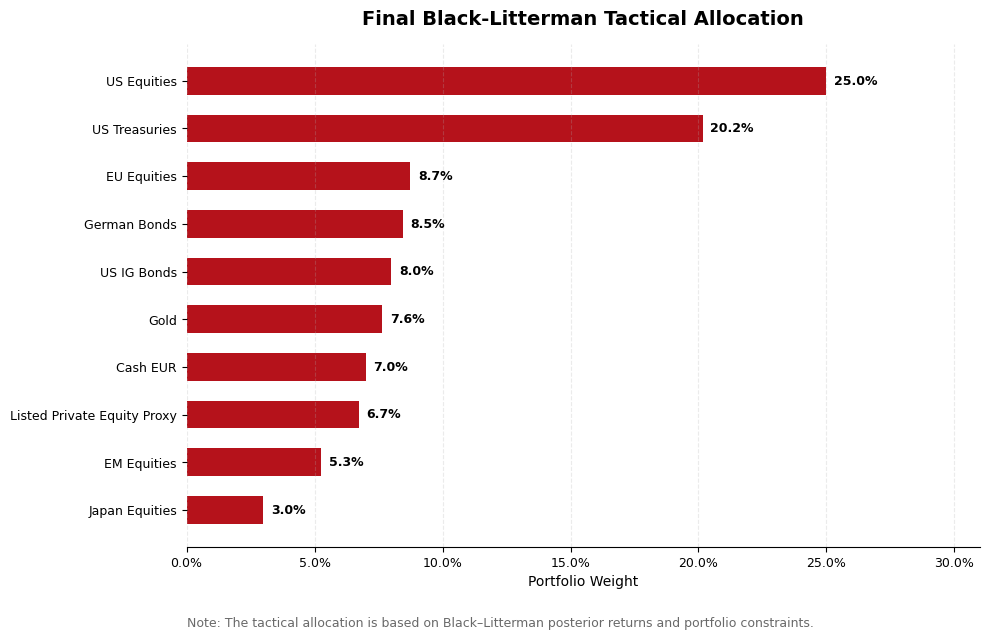

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))

final_taa_plot = tactical_weights.copy()
final_taa_plot.index = [asset_names[ticker] for ticker in final_taa_plot.index]
final_taa_plot = final_taa_plot.sort_values(ascending=True)

bars = ax.barh(
    final_taa_plot.index,
    final_taa_plot.values,
    color="#b5121b",
    height=0.58
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1%}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_title(
    "Final Black-Litterman Tactical Allocation",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Portfolio Weight")
ax.set_ylabel("")
ax.set_xlim(0, final_taa_plot.max() + 0.06)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)

ax.text(
    0,
    -0.16,
    "Note: The tactical allocation is based on Black–Litterman posterior returns and portfolio constraints.",
    transform=ax.transAxes,
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.show()

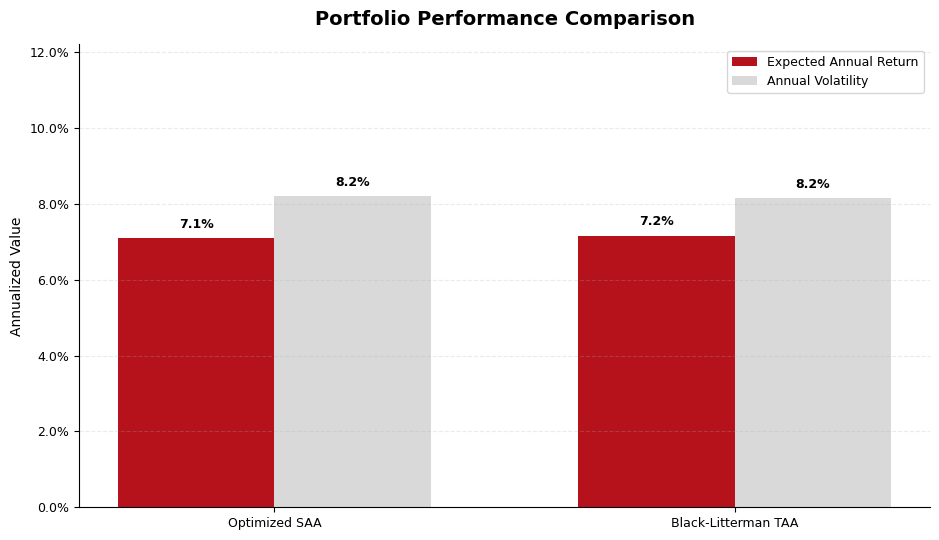

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))

performance_plot = final_statistics.set_index("Portfolio")[
    ["Expected Annual Return", "Annual Volatility"]
]

x = np.arange(len(performance_plot.index))
bar_width = 0.34

bars_return = ax.bar(
    x - bar_width / 2,
    performance_plot["Expected Annual Return"],
    width=bar_width,
    label="Expected Annual Return",
    color="#b5121b"
)

bars_volatility = ax.bar(
    x + bar_width / 2,
    performance_plot["Annual Volatility"],
    width=bar_width,
    label="Annual Volatility",
    color="#d9d9d9"
)

for bars in [bars_return, bars_volatility]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(performance_plot.index)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_title(
    "Portfolio Performance Comparison",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_ylabel("Annualized Value")
ax.set_xlabel("")
ax.set_ylim(0, performance_plot.max().max() + 0.04)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=9
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()

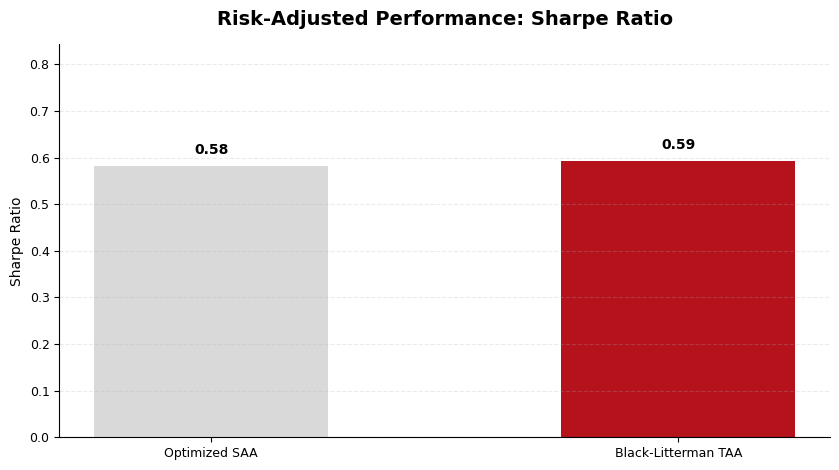

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

sharpe_plot = final_statistics.set_index("Portfolio")["Sharpe Ratio"]

bars = ax.bar(
    sharpe_plot.index,
    sharpe_plot.values,
    color=["#d9d9d9", "#b5121b"],
    width=0.5
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Risk-Adjusted Performance: Sharpe Ratio",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("")
ax.set_ylim(0, sharpe_plot.max() + 0.25)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()

**INTERPRETATION AND CONCLUSION**